# Andrew Kozlevcar

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

# Question 1

## Part A

In [54]:
X = [1, 1.75, 2, 3, 3.25, 4]

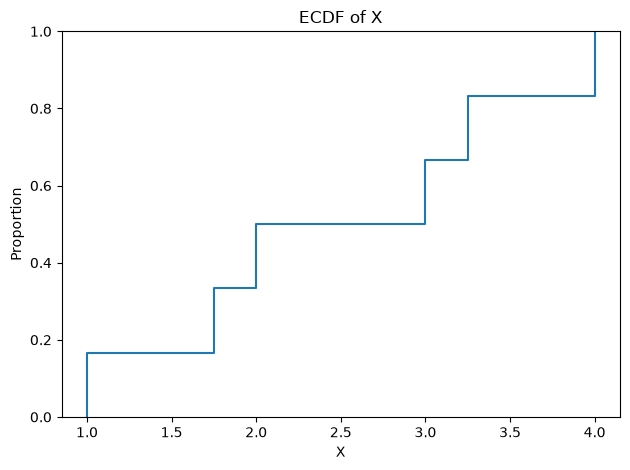

In [ ]:
# ECDF plot
sns.ecdfplot(x=X)

# Labels and titles
plt.xlabel("X")
plt.ylabel("Proportion")
plt.title("ECDF of X")
plt.tight_layout()
plt.show()


## Part B

I will make use of some functions from this week's notes:

In [56]:
def silverman_bandwidth(X, kernel="uniform"):
    """Silverman's rule-of-thumb bandwidth. `kernel` selects the constant."""
    const = {"uniform": 1.84, "gaussian": 1.06}[kernel]
    return const * np.std(X) * len(X) ** (-0.2)


def kde_grid(X, h, pad=2.0, K=200):
    """The evaluation grid shared by every estimator below."""
    X = np.asarray(X)
    return np.linspace(X.min() - pad * h, X.max() + pad * h, K)


def uniform_kde(X, grid, h):
    """f_hat_h(x) on `grid`, uniform kernel. Pure computation, no plotting."""
    X = np.asarray(X)
    n = len(X)
    I = np.abs(grid[:, None] - X[None, :]) < h
    return I.sum(axis=1) / (2 * n * h)

def gaussian_kde(X, grid, h):
    """f_hat_h(x) on `grid`, Gaussian kernel."""
    X = np.asarray(X)
    n = len(X)
    Z = (grid[:, None] - X[None, :]) / h
    phi = np.exp(-Z**2 / 2) / np.sqrt(2 * np.pi)
    return phi.sum(axis=1) / (n * h)


def plot_density(grid, f_hat, **kwargs):
    """One shared plotting routine, reused for both single curves and bump stacks."""
    plt.step(grid, f_hat, where="mid", **kwargs)

First, we compute the uniform KDE with $h= 0.2$:

Text(0.5, 1.0, 'Uniform KDE of X (h = 0.2)')

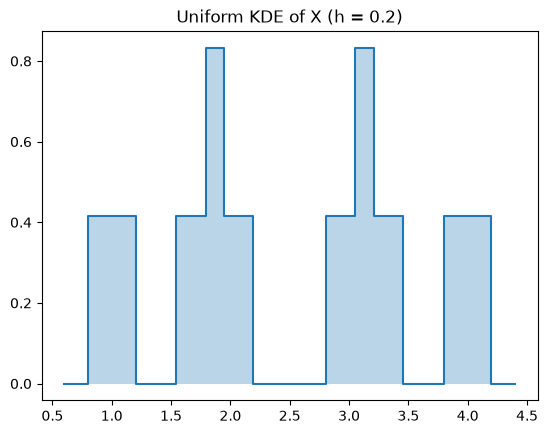

In [ ]:
h = 0.2

# Compute desired range of values
grid = kde_grid(X, h)

# Compute f_hat
f_hat = uniform_kde(X, grid, h)

# Plot density, fill for view improvement
plot_density(grid, f_hat)
plt.fill_between(
        grid, f_hat,
        step="mid",
        alpha=0.3)

# Titles
plt.title(f"Uniform KDE of X (h = {h})")

## Part C

Again, I will make use of the function from lecture:

In [58]:
h = silverman_bandwidth(X)

h

np.float64(1.2991670409500977)

## Part D

Text(0.5, 1.0, 'Uniform KDE of X (h = 1.2991670409500977)')

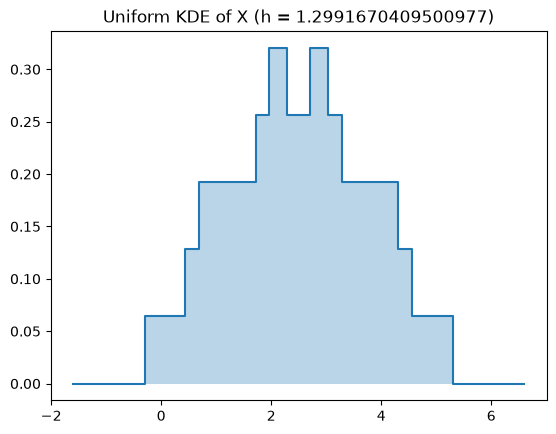

In [ ]:
# Compute desired range of values
grid = kde_grid(X, h)

# Compute f_hat
f_hat = uniform_kde(X, grid, h)

# Plot density, fill for aesthetic purposes, title
plot_density(grid, f_hat)
plt.fill_between(
        grid, f_hat,
        step="mid",
        alpha=0.3)
plt.title(f"Uniform KDE of X (h = {h})")

## Part E

From above, we see that b and d look very different. Moreover, in part b, our six values create four bins, with two of these bins containing a single value and two of these bins containing two values. In general, these bins contains too few values, suggesting the bandwith is too small relative to the spread of our data and the number of points. If we were to repeat this process many times, each resulting KDE would vary dramatically (high variance), though its estimates for individual points will be closer to the true density on average (low bias). In part d, we instead opt for Silverman's bandwidth, which is $h = 1.3$. The result is a contigous, bell-shaped region that appears roughly symmetric about $2.5$. In this case, there is sufficient (but not excessive) overlap between bins, suggesting that the bandwith is appropriate for the spread of our data and the number of points. As compared to b, a KDE estimate with this bandwith will have lower variance (repeeated samples would produce similarly shaped estimates) but higher bias (taking a larger $h$ moves us further from the guaranteed convergence that takes place as $h \to 0$). 

# Question 2

As per the notes, I did not include the endpoint $h$ in any of my computed intervals; whether you do or don't is a matter of convention, and our notes chose not to.

## Part A

By one of our definitions in class, $\hat{f}_h(x) = \frac{1}{2nh}\sum_{i = 1}^{n} I_{|X_i - x| < h}$. Evaluating at $h = 0.6$, $n=5$, and $x = 0$, we have $\hat{f}_h(0) = \frac{1}{2(5)(0.6)}\sum_{i = 1}^{5} I_{|X_i - 0| < h}$. Since $0$, $-0.5$, and $0.5$ are within $0.6$ of $0$ while $-1$ and $1$ are not, we have $\hat{f}_h(0) = \frac{1}{2(5)(0.6)}(3) = \frac{1}{2}$. 

## Part B

Let us begin by taking expectation without values: $E[\hat{f}_h(x)] = E[\frac{1}{2nh}\sum_{i = 1}^{n} I_{|X_i - x| < h}] = \frac{1}{2nh}\sum_{i = 1}^{n} E[I_{|X_i - x| < h}]$. For any $i$, $I_{|X_i - x| < h}$ is a random variable that takes on a value of $1$ with probability $P(x - h < X_i < x + h) = P(x - h < X_i \leq x + h) = F(x+h) - F(x-h)$ (the second equality is due to $X_i$ being a continous random variable and thus $P(X_i = x + h) = 0$ ) and $0$ with probability $1 - P(x - h < X_i < x + h)$. Trivially, $E[I_{|X_i - x| < h}] = F(x+h) - F(x-h)$, and so $E[\hat{f}_h(x)] = \frac{1}{2nh}\sum_{i = 1}^{n} E[I_{|X_i - x| < h}] = \frac{1}{2nh}\sum_{i = 1}^{n} (F(x+h) - F(x-h)) = \frac{F(x+h) - F(x-h)}{2h}$.

Evaluating at $h=0.6$ and $x = 0$ gives $E[\hat{f}_h(0)] = \frac{F(0.6) - F(-0.6)}{2(0.6)} = \frac{F(0.6) - F(-0.6)}{2(0.6)} \approx 0.3762$ (I used the CDF function on my calculator). 

## Part C

By definition, $f(0)=\frac{1}{\sqrt{2\pi}}e^{-0^2/2} = \frac{1}{\sqrt{2\pi}} \approx 0.39894$

## Part D

With the given $h = 0.6$, we see that $E[\hat{f}_h(0)] \approx 0.3762 \neq 0.39894 \approx f(0)$. Since the expectation of our estimator is not equal to the density it is attempting to estimate, the estimator is biased at $x = 0$ by definition; whether it is biased at other x values cannot be extrapolated--we must instead prove generally that is biased.

## Part E

Using the general derivation from above and evaluating at $h=0.1$ and $x = 0$ gives $E[\hat{f}_h(0)] = \frac{F(0.1) - F(-0.1)}{2(0.1)} = \frac{F(0.1) - F(-0.1)}{2(0.1)} \approx 0.3983$ (I used the CDF function on my calculator). 

When $h = 0.6$, the gap between the expectation of our estimator and $f(0)$ was approximately $0.02274$. With $h = 0.1$, the gap between the expectation of our estimator and $f(0)$ is now approximately $0.0064$. Clearly, this second value is much smaller, suggesting (but not proving) that $E[\hat{f}_h(0)] \to f(0)$ as $h \to 0$.

## Part F

Applied to our situation, a consistent estimator satisfies $E[\hat{f}_h(0)] \to f(0)$ as $n \to \infty$, where $n$ is the sample size. As suggested above, $E[\hat{f}_h(0)] \to f(0)$ as $h \to 0$, but if $h$ is unconstrained and $n \to \infty$, then the claim of consistency does not hold; an unconstrained/indepedent/free $h$ can take on any value at any $n$ (including remaining fixed). Thus, for our estimator to be consistent, we need to make $h$ a function of $n$ such that as $n \to \infty$, we have that $h \to 0$, which will guarantee the limiting behavior observed/conjectured above.

## Part G

I will approach this problem as if our sample size and sample is fixed, and we are looking to choose a bandwidth. In that case, note that smaller and smaller bandwidths will provide us a less biased estimate by the discussion above. This is beneficial, but we have a competing force: the variance of our estimator. That is, with a fixed $n$ and sample, variance grows unbounded as $h$ becomes increasingly small. This is a bias-variance optimization; we want to choose $h$ small enough to limit bias but large enough to limit an explosion of variance. Beyond the scope of this course, it can be shown that choosing $h$ so that it is directly proportional to standard deviation and inversely related to a fractional power of $n$ optimizes this trade-off. Intuitively, this makes sense. We can loosely visualize the variance of our distribution as the number of non-contigous blocks that our estimator produces on average. If standard deviation decreases, then our observations are more closely packed, which means that we can use a smaller bandwidth and still achieve the same "contiguity" between the density contributions of distinct observations. On the other hand, if sample size increases (and standard deviation remains the same), then we have more points populating roughly the same space, which means the typical distance between any two observations is reduced on average; this means a smaller bandwidth is required to achieve the same "contiguity" between the density contributions of distinct observations.

# Question 3

## Part A

While I could repeat the same type of work I did in the first question, I will just use the pre-defined functions from class:

In [ ]:
# Intialize X
X = np.array([5, 7, 7, 8, 10])

# Identify the values we want to evaluate at
grid = np.array([6, 6.5, 7, 8, 8.5])

# Specify h
h = 1.5

# Compute our uniform kde
f_hat_uniform = uniform_kde(X, grid, h)

f_hat_uniform

array([0.2       , 0.13333333, 0.2       , 0.2       , 0.06666667])

## Part B

In [ ]:
# Compute our gaussian kde
f_hat_gaussian = gaussian_kde(X, grid, h)

f_hat_gaussian

array([0.15116668, 0.16865731, 0.17804448, 0.16744524, 0.15060231])

## Part C

In the Gaussian case, we see that from $x= 8$ to $x=8.5$, the density estimate jumps from $0.2$ to $0.06666667$; in the same region for the Gaussian kde, the density estimate jumps from $0.167$ to $0.150$, a much smaller gap. The best way to understand why we see this jump in the uniform KDE but not the Gaussian KDE is through the mini density lens. Each data point contributes a "mini" density centered at its observation and whose spread is related to the fixed bandwidth. In the case of uniform KDEs, these mini densities are uniform densities. Uniform densities, in some sense, are binary; a fixed  region around the observation is given a fixed non-zero density, wheresd all other regions are given zero density. As a result, there is a sharp drop-off in density when we reach the end of the bandwidth (relative to an observation). While the mini densities of Gaussian KDEs also places most density near the observation and provide increasingly less density as you move away from the observation, there is no "binary" drop-off. Instead, the density contribution gradually reduces as you move away from the observation but never achieves zero across the entire range. At $x = 8.5$, the density for the two $x=7$ observations abruptly ends for the uniform KDEs, which results in a massive reduction. Alternatively, for the normal KDE, the contributions of these observations persist (and in fact all the previous points continue to contribute), but at an increasingly reduced amount. 

## Part D

As highlighted in the description above, the Gaussian kernel produces a smoother density estimate because the mini densities it is composed of are smoother (that is, there is no binary drop-off in density contribution, just a gradual reduction in density over the entire range). Depending on our use case, we may expect that the density of our modeled phenomenom to be smoother; this is entirely domain-specific, but often occurs when we are considering large sample phenomenom. In that case, a gaussian KDE may be more suitable. However, the uniform kernel is often easier to compute and interpret, and there are possibly domain-specific circumstances where we expect there to be more abrupt shifts in the desnity; a uniform density estimate can capture these sharp corners better. 

# Question 4

## Part A

First, we read in the data:

In [63]:
df = pd.read_csv("data/heart_failure_clinical_records_dataset.csv")

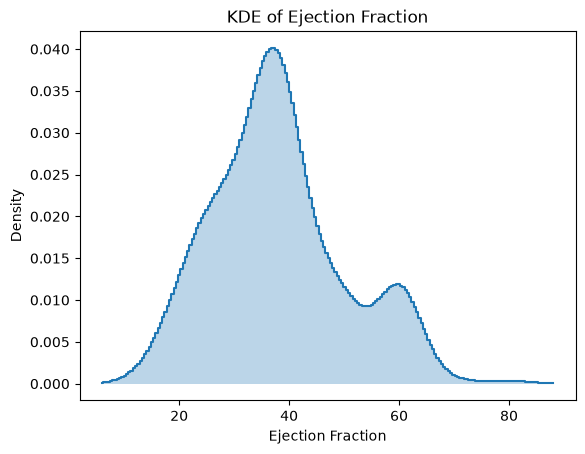

In [ ]:
# Extract X, set h, compute grid, and compute f_hat
X = df["ejection_fraction"].to_numpy()
h = silverman_bandwidth(X, kernel="gaussian")
grid = kde_grid(X, h)
f_hat = gaussian_kde(X, grid, h)

# Plot densities
plot_density(grid, f_hat)
plt.fill_between(
        grid, f_hat,
        step="mid",
        alpha=0.3)

# Labels
plt.xlabel("Ejection Fraction")
plt.ylabel("Density")
plt.title("KDE of Ejection Fraction")
plt.show()

## Part B

Note that I will not fill the densities to make comparisons easier.

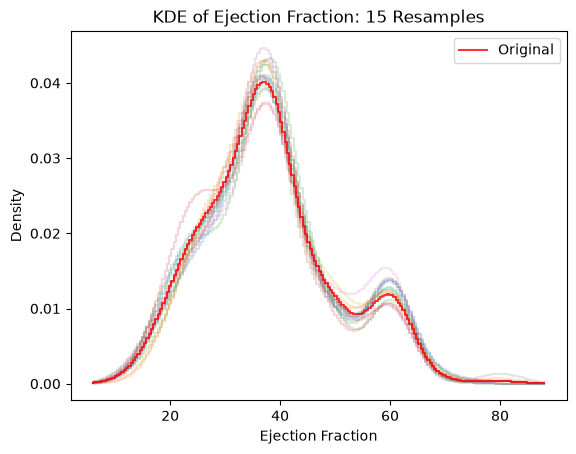

In [ ]:
# Extract X, set h, compute grid, and compute f_hat
X = df["ejection_fraction"].to_numpy()
h = silverman_bandwidth(X, kernel="gaussian")
grid = kde_grid(X, h)

# Perform bootstraps
for i in range(15):
    # Sample, extract sample, compute f_hat_sample
    sample = df.sample(frac=1.0, replace=True)
    X_sample = sample["ejection_fraction"].to_numpy()
    f_hat_sample = gaussian_kde(X_sample, grid, h)

    # Plot f_hat sample
    plot_density(grid, f_hat_sample, alpha=0.2)

# Plot true density
f_hat = gaussian_kde(X, grid, h)
plot_density(grid, f_hat, alpha=0.8, color="red", label="Original")

# Labels
plt.xlabel("Ejection Fraction")
plt.ylabel("Density")
plt.title("KDE of Ejection Fraction: 15 Resamples")
plt.legend()
plt.show()

For the most part, the ejection fraction density estimate is most reliable in the region below $20$, between $40$ and $50$, and beyond $65$. In these regions, the sample lines are all tightly clustered around the original line. However, in the regions between $20$ and $40$ and $50$ and $60$, the ejection fraction density estimate is least reliable; the sample lines are much more varied. Interestingly, these points of high variation are where relative extrema occur (local minimums and maximums); the points of low variation are primarily in regions where there are no extrema.